# SPICE vs PHOEBE bolometric light-curve comparison

Loads the per-grid-point pickles produced by `check_phoebe_eclipses.py` and
compares the bolometric eclipse light curves from SPICE against PHOEBE.

Each pickle contains:
- `fluxes_phoebe` — PHOEBE bolometric flux (linear, erg/s/cm^2)
- `bol_lum`       — SPICE AB magnitudes already zeroed at `t=0`
- `times`         — sample times in days, primary then secondary eclipse
- scalar params: `inclination`, `period`, `q`, `ecc`, `primary_mass`, `secondary_mass`, `sma`, `n_times`

In [62]:
import glob
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

In [63]:
# Pickle directories produced by check_phoebe_eclipses.py (--output_path).
# Override ECLIPSE_BASE if your runs live elsewhere.
ECLIPSE_BASE = Path('/home/100/mj8805/scr_y89/spice_eclipses')
MESH_DIRS = {
    'mesh5k': ECLIPSE_BASE / 'mesh5k',
    'mesh20k': ECLIPSE_BASE / 'mesh20k',
}
RESULTS_DIR = MESH_DIRS['mesh20k']  # default for the single-grid example below

pkl_files = sorted(glob.glob(str(RESULTS_DIR / 'eclipses_*.pkl')))
print(f'{len(pkl_files)} pickle(s) under {RESULTS_DIR}')
for label, mesh_dir in MESH_DIRS.items():
    n = len(glob.glob(str(mesh_dir / 'eclipses_*.pkl')))
    print(f'  {label}: {n} pickle(s) under {mesh_dir}')

48 pickle(s) under /home/100/mj8805/scr_y89/spice_eclipses/mesh20k
  mesh5k: 295 pickle(s) under /home/100/mj8805/scr_y89/spice_eclipses/mesh5k
  mesh20k: 48 pickle(s) under /home/100/mj8805/scr_y89/spice_eclipses/mesh20k


In [64]:
def phoebe_flux_to_mag(flux):
    """PHOEBE bolometric flux -> magnitude, zeroed at the first sample."""
    flux = np.asarray(flux, dtype=float)
    mag = -2.5 * np.log10(flux)
    return mag - mag[0]


def load_run(path):
    """Load one pickle and pull out everything needed for a comparison plot."""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    times = np.asarray(data['times'])
    spice_mag = np.asarray(data['bol_lum'])  # already zeroed in check_phoebe_eclipses.py
    phoebe_mag = phoebe_flux_to_mag(data['fluxes_phoebe'])
    return {
        'path': path,
        'times': times,
        'spice_mag': spice_mag,
        'phoebe_mag': phoebe_mag,
        'residual': spice_mag - phoebe_mag,
        'inclination': float(data['inclination']),
        'period': float(data['period']),
        'q': float(data['q']),
        'ecc': float(data['ecc']),
        'primary_mass': float(data['primary_mass']),
        'secondary_mass': float(data['secondary_mass']),
    }

## Single grid point

Quick visual check on one pickle: PHOEBE vs SPICE bolometric light curves and the residual.

In [65]:
assert pkl_files, f'No pickles in {RESULTS_DIR}; run check_phoebe_eclipses.py first.'
example = load_run(pkl_files[0])
print(os.path.basename(example['path']))
print(f"incl={example['inclination']}, P={example['period']} d, "
      f"q={example['q']}, ecc={example['ecc']}, m1={example['primary_mass']}")

eclipses_incl_85.0_period_12.8889_q_0.625_ecc_0.4_primary_mass_1.0_nmesh_20000.pkl
incl=85.0, P=12.8889 d, q=0.625, ecc=0.4, m1=1.0


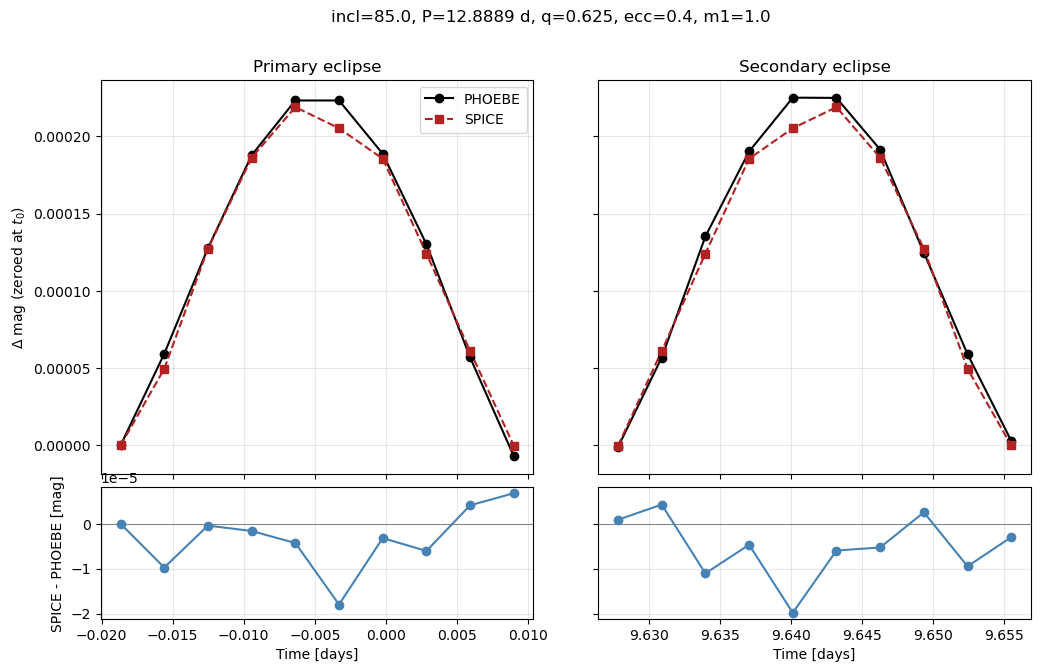

max |residual| = 1.9811e-05 mag
rms residual   = 7.9776e-06 mag


In [66]:
# check_phoebe_eclipses.py concatenates [primary-eclipse window, secondary-eclipse window],
# so the time axis isn't monotonic. Split it back into the two windows for plotting.
half = len(example['times']) // 2
t_primary = example['times'][:half]
t_secondary = example['times'][half:]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col', sharey='row',
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05, 'wspace': 0.15})

for ax_lc, ax_res, t, label in (
    (axes[0, 0], axes[1, 0], t_primary, 'Primary eclipse'),
    (axes[0, 1], axes[1, 1], t_secondary, 'Secondary eclipse'),
):
    sl = slice(0, half) if label == 'Primary eclipse' else slice(half, None)
    ax_lc.plot(t, example['phoebe_mag'][sl], 'o-', label='PHOEBE', color='black')
    ax_lc.plot(t, example['spice_mag'][sl], 's--', label='SPICE', color='firebrick')
    ax_lc.invert_yaxis()
    ax_lc.set_title(label)
    ax_lc.grid(alpha=0.3)

    ax_res.axhline(0, color='gray', lw=0.7)
    ax_res.plot(t, example['residual'][sl], 'o-', color='steelblue')
    ax_res.set_xlabel('Time [days]')
    ax_res.grid(alpha=0.3)

axes[0, 0].set_ylabel(r'$\Delta$ mag (zeroed at $t_0$)')
axes[1, 0].set_ylabel('SPICE - PHOEBE [mag]')
axes[0, 0].legend(loc='best')
fig.suptitle(
    f"incl={example['inclination']}, P={example['period']} d, "
    f"q={example['q']}, ecc={example['ecc']}, m1={example['primary_mass']}"
)
plt.show()

print(f"max |residual| = {np.nanmax(np.abs(example['residual'])):.4e} mag")
print(f"rms residual   = {np.sqrt(np.nanmean(example['residual']**2)):.4e} mag")

## Grid summary

Aggregate residual statistics across every pickle in `RESULTS_DIR`.

In [67]:
ECC_MAX_MESH5K = 0.6
ECC_MAX_MESH20K = 0.4
INCL_FILTER = 90.0
ECC_MAX_BY_MESH = {'mesh5k': ECC_MAX_MESH5K, 'mesh20k': ECC_MAX_MESH20K}


def runs_to_summary(runs):
    return pd.DataFrame([
        {
            'inclination': r['inclination'],
            'period': r['period'],
            'q': r['q'],
            'ecc': r['ecc'],
            'primary_mass': r['primary_mass'],
            'secondary_mass': r['secondary_mass'],
            'max_abs_residual': float(np.nanmax(np.abs(r['residual']))),
            'rms_residual': float(np.sqrt(np.nanmean(r['residual']**2))),
            'mean_residual': float(np.nanmean(r['residual'])),
        }
        for r in runs
    ])


def load_mesh_runs(results_dir, ecc_max, inclination=INCL_FILTER):
    paths = sorted(glob.glob(str(results_dir / 'eclipses_*.pkl')))
    mesh_runs = []
    for path in tqdm(paths, desc=results_dir.name):
        try:
            mesh_runs.append(load_run(path))
        except Exception as exc:
            print(f'[skip] {os.path.basename(path)}: {exc}')
    n_before = len(mesh_runs)
    mesh_runs = [
        r for r in mesh_runs
        if r['ecc'] <= ecc_max and r['inclination'] == inclination
    ]
    print(
        f'{results_dir.name}: kept {len(mesh_runs)}/{n_before} runs '
        f'(ecc <= {ecc_max}, incl={inclination})'
    )
    return mesh_runs


mesh_runs = {}
summaries = {}
for label, mesh_dir in MESH_DIRS.items():
    ecc_max = ECC_MAX_BY_MESH[label]
    mesh_runs[label] = load_mesh_runs(mesh_dir, ecc_max=ecc_max)
    summaries[label] = runs_to_summary(mesh_runs[label])

runs = mesh_runs['mesh20k']
summary = summaries['mesh20k']
summary.head()

mesh5k: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 295/295 [02:40<00:00,  1.83it/s]


mesh5k: kept 150/295 runs (ecc <= 0.6, incl=90.0)


mesh20k: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:57<00:00,  1.21s/it]


mesh20k: kept 30/48 runs (ecc <= 0.4, incl=90.0)


,inclination,period,q,ecc,primary_mass,secondary_mass,max_abs_residual,rms_residual,mean_residual
0,90.0,100.0,0.500,0.177778,1.0,0.500,0.000904,0.000479,-0.000359
1,90.0,100.0,0.625,0.000000,1.0,0.625,0.000909,0.000614,-0.000494
2,90.0,100.0,0.625,0.200000,1.0,0.625,0.000913,0.000617,-0.000498
3,90.0,100.0,0.625,0.400000,1.0,0.625,0.000903,0.000612,-0.000493
4,90.0,100.0,0.750,0.000000,1.0,0.750,0.000908,0.000614,-0.000494


In [68]:
import matplotlib
%matplotlib inline

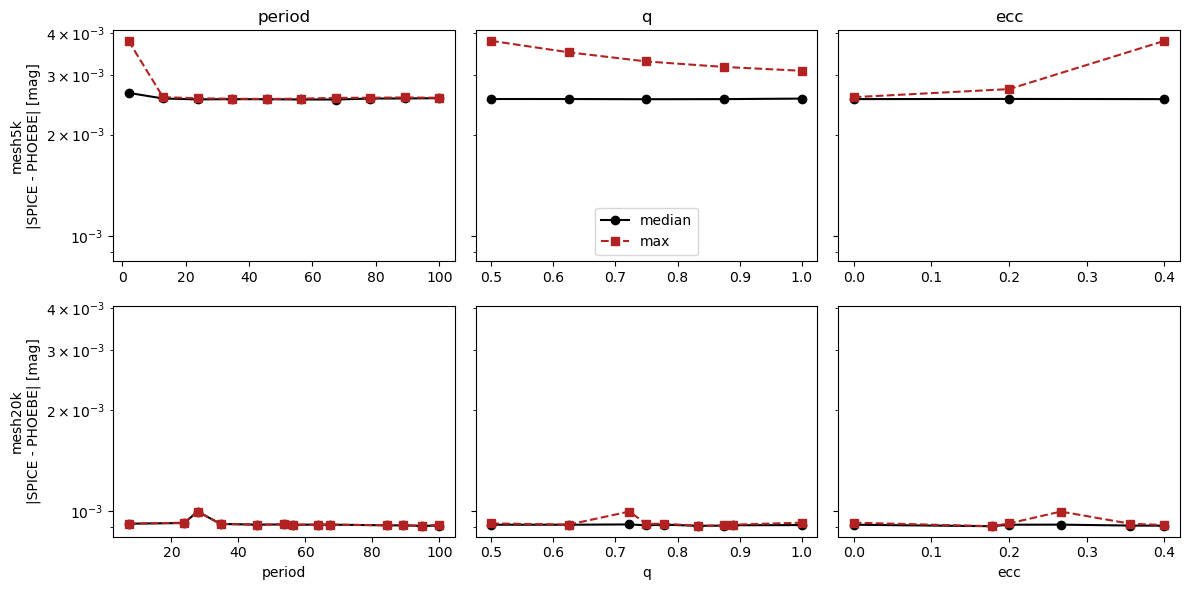

In [76]:
# Median / max residual vs grid parameter — 2 mesh rows × 3 parameter columns, shared y.
params = ['period', 'q', 'ecc']
mesh_order = ['mesh5k', 'mesh20k']

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

for irow, mesh in enumerate(mesh_order):
    for icol, param in enumerate(params):
        ax = axes[irow, icol]
        g = (
            summaries[mesh]
            .groupby(param)['max_abs_residual']
            .agg(['median', 'max'])
            .reset_index()
        )
        if len(g) <= 1:
            ax.text(0.5, 0.5, f'{param}: single value', transform=ax.transAxes, ha='center')
            ax.set_xticks([])
        else:
            ax.plot(g[param], g['median'], 'o-', label='median', color='black')
            ax.plot(g[param], g['max'], 's--', label='max', color='firebrick')
            ax.set_yscale('log')
        if irow == 0:
            ax.set_title(param)
        if irow == len(mesh_order) - 1:
            ax.set_xlabel(param)
        if icol == 0:
            ax.set_ylabel(f'{mesh}\n|SPICE - PHOEBE| [mag]')

axes[0, 1].legend(loc='lower center')
plt.tight_layout()
plt.show()

In [77]:
fig.savefig('blackbody_comparison_mesh.pdf', bbox_inches='tight')

In [51]:
# Worst grid points by max |residual| — useful for picking pickles to re-plot above.
summary.sort_values('max_abs_residual', ascending=False).head(10)

,inclination,period,q,ecc,primary_mass,secondary_mass,max_abs_residual,rms_residual,mean_residual
17,90.0,27.7895,0.722222,0.266667,1.0,0.722222,0.000999,0.000516,-0.000398
16,90.0,23.7778,1.000000,0.000000,1.0,1.000000,0.000926,0.000620,-0.000497
21,90.0,48.4211,0.666667,0.533333,1.0,0.666667,0.000923,0.000485,-0.000365
15,90.0,23.7778,0.500000,0.200000,1.0,0.500000,0.000921,0.000602,-0.000483
28,90.0,7.1579,0.777778,0.355556,1.0,0.777778,0.000919,0.000439,-0.000294
18,90.0,34.6667,0.750000,0.000000,1.0,0.750000,0.000918,0.000613,-0.000493
14,90.0,100.0000,1.000000,0.533333,1.0,1.000000,0.000917,0.000482,-0.000362
19,90.0,38.1053,0.500000,0.533333,1.0,0.500000,0.000917,0.000474,-0.000349
22,90.0,53.5789,0.722222,0.266667,1.0,0.722222,0.000915,0.000507,-0.000393
25,90.0,67.3333,0.625000,0.000000,1.0,0.625000,0.000914,0.000614,-0.000494


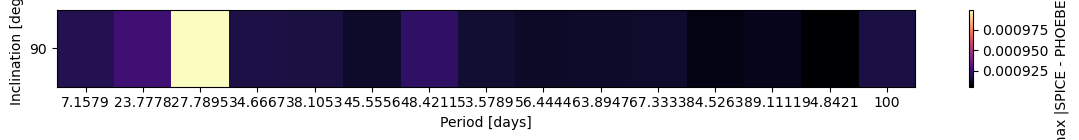

In [52]:
# Inclination x period heatmap of the max residual (collapses q/ecc/m1 by max).
if {'inclination', 'period'}.issubset(summary.columns) and len(summary) > 1:
    pivot = summary.pivot_table(
        index='inclination', columns='period',
        values='max_abs_residual', aggfunc='max',
    )
    fig, ax = plt.subplots(figsize=(1 + 0.7 * pivot.shape[1], 1 + 0.5 * pivot.shape[0]))
    im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                   extent=(0, pivot.shape[1], 0, pivot.shape[0]),
                   cmap='magma')
    ax.set_xticks(np.arange(pivot.shape[1]) + 0.5)
    ax.set_xticklabels([f'{c:g}' for c in pivot.columns])
    ax.set_yticks(np.arange(pivot.shape[0]) + 0.5)
    ax.set_yticklabels([f'{r:g}' for r in pivot.index])
    ax.set_xlabel('Period [days]')
    ax.set_ylabel('Inclination [deg]')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('max |SPICE - PHOEBE| [mag]')
    plt.tight_layout()
    plt.show()
else:
    print('Need >1 (inclination, period) grid points for a heatmap.')

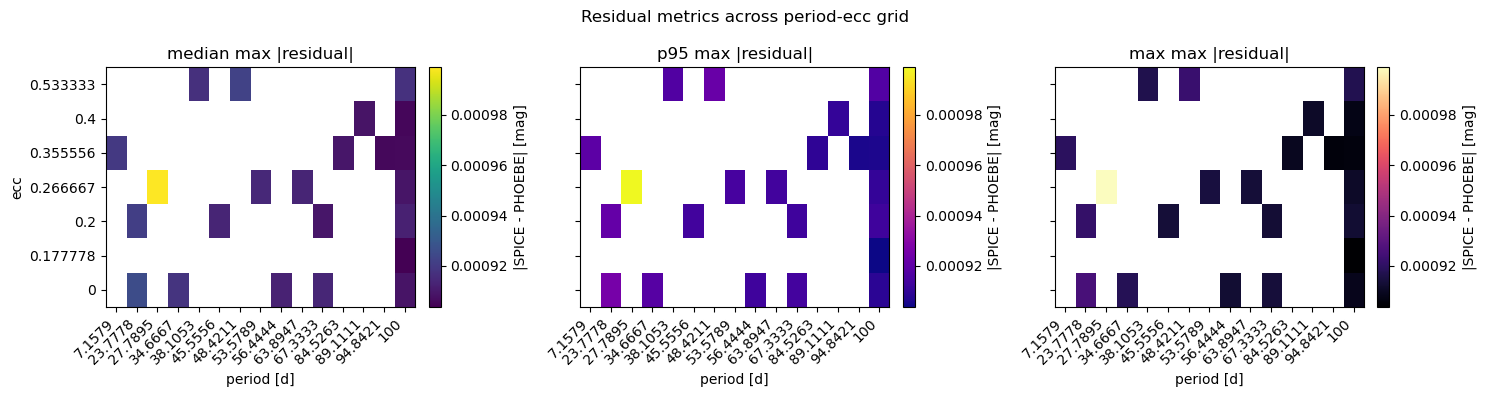

Per-ecc sample statistics (count + quantiles of max_abs_residual):


,ecc,n,median,p95,max
0,0.000000,7,0.000913,0.000923,0.000926
1,0.177778,1,0.000904,0.000904,0.000904
2,0.200000,7,0.000913,0.000919,0.000921
3,0.266667,5,0.000913,0.000982,0.000999
4,0.355556,4,0.000908,0.000918,0.000919
5,0.400000,6,0.000907,0.000910,0.000911
6,0.533333,3,0.000917,0.000922,0.000923


No runs for period=2.0 and ecc=0.4
No runs for period=2.0 and ecc=0.6


/jobfs/168853102.gadi-pbs/ipykernel_832162/4285157394.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc='best', fontsize=8)


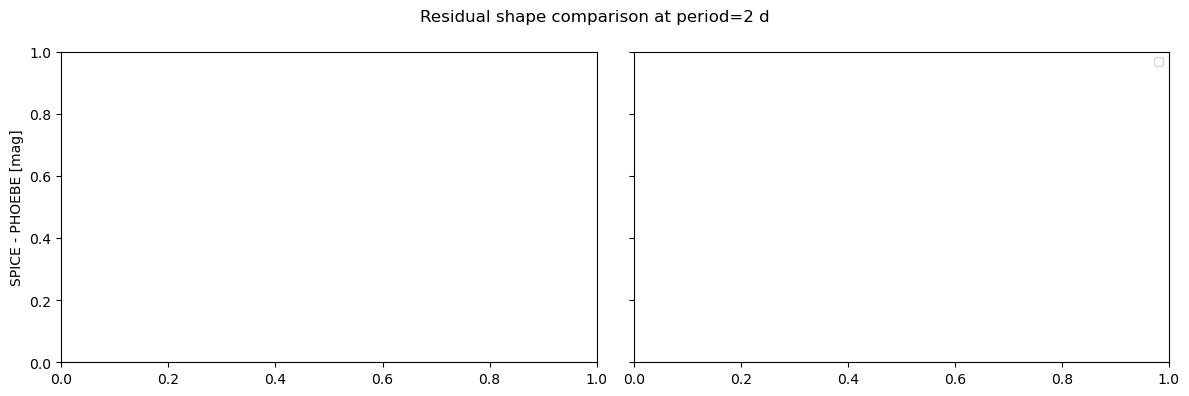

In [53]:
# Diagnostics for the apparent ecc=0.6 spike.
# Goal: separate true ecc behavior from period/ecc interactions and sample-count artifacts.
# Runs with ecc > 0.6 are filtered out upstream, so we no longer probe ecc=0.8 here.

target_period = 2.0
target_eccs = [0.4, 0.6]

# 1) period x ecc residual summary (max / median / p95)
pe = (
    summary.groupby(['period', 'ecc'])['max_abs_residual']
    .agg(max='max', median='median', p95=lambda x: np.nanpercentile(x, 95))
    .reset_index()
)

periods = np.sort(pe['period'].unique())
eccs = np.sort(pe['ecc'].unique())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric, cmap in zip(axes, ['median', 'p95', 'max'], ['viridis', 'plasma', 'magma']):
    pivot = pe.pivot(index='ecc', columns='period', values=metric).reindex(index=eccs, columns=periods)
    im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap=cmap)
    ax.set_title(f'{metric} max |residual|')
    ax.set_xlabel('period [d]')
    ax.set_xticks(np.arange(len(periods)))
    ax.set_xticklabels([f'{p:g}' for p in periods], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(eccs)))
    ax.set_yticklabels([f'{e:g}' for e in eccs])
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('|SPICE - PHOEBE| [mag]')
axes[0].set_ylabel('ecc')
fig.suptitle('Residual metrics across period-ecc grid')
plt.tight_layout()
plt.show()

# 2) sample counts and quantiles per eccentricity
print('Per-ecc sample statistics (count + quantiles of max_abs_residual):')
ecc_stats = (
    summary.groupby('ecc')['max_abs_residual']
    .agg(n='size', median='median', p95=lambda x: np.nanpercentile(x, 95), max='max')
    .reset_index()
    .sort_values('ecc')
)
display(ecc_stats)

# 3) phase-aligned residual overlays at period ~2.0 for ecc=0.4/0.6/0.8
# Pick, for each target ecc, the run with the largest max_abs_residual at that period.
run_lookup = {
    (r['inclination'], r['period'], r['q'], r['ecc'], r['primary_mass'], r['secondary_mass']): i
    for i, r in enumerate(runs)
}

subset = summary[np.isclose(summary['period'], target_period)].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ecc in target_eccs:
    candidates = subset[np.isclose(subset['ecc'], ecc)]
    if candidates.empty:
        print(f'No runs for period={target_period} and ecc={ecc}')
        continue

    row = candidates.sort_values('max_abs_residual', ascending=False).iloc[0]
    key = (
        float(row['inclination']), float(row['period']), float(row['q']), float(row['ecc']),
        float(row['primary_mass']), float(row['secondary_mass'])
    )
    run_idx = run_lookup.get(key)
    if run_idx is None:
        print(f'Could not match run for ecc={ecc} at period={target_period}')
        continue

    rr = runs[run_idx]
    half = len(rr['times']) // 2

    for ax, sl, title in [
        (axes[0], slice(0, half), 'Primary eclipse window'),
        (axes[1], slice(half, None), 'Secondary eclipse window'),
    ]:
        t = rr['times'][sl]
        phase = (t - np.nanmin(t)) / (np.nanmax(t) - np.nanmin(t) + 1e-15)
        ax.plot(phase, rr['residual'][sl], marker='o', ms=3, lw=1.2,
                label=(f"ecc={ecc:g}, incl={row['inclination']:g}, q={row['q']:g}, "
                       f"max={row['max_abs_residual']:.3e}"))
        ax.axhline(0.0, color='gray', lw=0.8)
        ax.set_title(title)
        ax.set_xlabel('normalized phase in eclipse window')
        ax.grid(alpha=0.3)

axes[0].set_ylabel('SPICE - PHOEBE [mag]')
axes[1].legend(loc='best', fontsize=8)
fig.suptitle(f'Residual shape comparison at period={target_period:g} d')
plt.tight_layout()
plt.show()